# 09 — Support Vector Regressor (SVR) (Regression Track)
**23CSE301 Machine Learning — Capstone, Review 1**

**Dataset:** UK Used Cars (`used_cars.csv`) **Target:** `price` (£)

| Block | Rubric section |
|---|---|
| 1 | Section A — Dataset & EDA |
| 2 | Section B — Preprocessing & Feature Engineering |
| 3 | Section C — Regression Track (Support Vector Regressor) |

Support Vector Regression fits a function that keeps as many training points as possible **inside a tube of width ε** around it, and only penalises points outside the tube. **C** controls how strongly those errors are penalised (large C = less regularisation). A **kernel** (linear, polynomial, RBF) lets SVR fit non-linear relationships. SVR is based on distances/dot products, so **feature scaling is essential**.

---
# BLOCK 1 — Dataset & EDA (Section A)

In [1]:
# ============================================================
# BLOCK 1 : DATASET & EDA
# ============================================================

# ---- 1.0 Imports & global settings ----
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                      # fixed seed for reproducibility (guideline 7.1)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")   # colour-blind-friendly palette (guideline 7.3)
pd.set_option("display.max_columns", 50)

DATA_PATH = "../data/used_cars.csv"    # change if your file is somewhere else
TARGET = "price"

## A1 — Dataset loading & audit
Shape, dtypes, missing values, duplicates and target distribution.

In [2]:
# ---- 1.1 Load the dataset ----
df = pd.read_csv(DATA_PATH)

# 'Unnamed: 0' is just an old row index saved into the CSV -> not a real feature
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Some text columns have stray spaces (e.g. ' T-Roc') -> strip them
for col in df.select_dtypes(include="object").columns.union(df.select_dtypes(include="string").columns):
    df[col] = df[col].astype(str).str.strip()

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (99187, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW


In [3]:
# ---- 1.2 Data types & basic info ----
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print("Duplicate rows:", df.duplicated().sum())
audit

Duplicate rows: 1475


,dtype,missing_count,missing_%,n_unique
model,str,0,0.0,195
year,int64,0,0.0,27
price,int64,0,0.0,13236
transmission,str,0,0.0,4
mileage,int64,0,0.0,42214
fuelType,str,0,0.0,5
tax,int64,0,0.0,48
mpg,float64,0,0.0,208
engineSize,float64,0,0.0,40
Make,str,0,0.0,9


In [4]:
# ---- 1.3 Statistical summary of numeric columns ----
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,99187.0,2017.087723,2.123934,1970.0,2016.0,2017.0,2019.0,2060.0
price,99187.0,16805.347656,9866.773417,450.0,9999.0,14495.0,20870.0,159999.0
mileage,99187.0,23058.914213,21148.523721,1.0,7425.0,17460.0,32339.0,323000.0
tax,99187.0,120.299838,63.150926,0.0,125.0,145.0,145.0,580.0
mpg,99187.0,55.166825,16.138522,0.3,47.1,54.3,62.8,470.8
engineSize,99187.0,1.663280,0.557646,0.0,1.2,1.6,2.0,6.6


In [5]:
# ---- 1.4 Target distribution summary ----
print(df[TARGET].describe())
print("\nSkewness of price:", round(df[TARGET].skew(), 3))

# Category counts (the 'class distribution' view for the categorical columns)
for col in ["Make", "transmission", "fuelType"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

count     99187.000000
mean      16805.347656
std        9866.773417
min         450.000000
25%        9999.000000
50%       14495.000000
75%       20870.000000
max      159999.000000
Name: price, dtype: float64

Skewness of price: 2.347

--- Make ---
Make
ford        17965
VW          15157
vauxhall    13632
merc        13119
BMW         10781
Audi        10668
toyota       6738
skoda        6267
hyundi       4860
Name: count, dtype: int64

--- transmission ---
transmission
Manual       56445
Semi-Auto    22677
Automatic    20056
Other            9
Name: count, dtype: int64

--- fuelType ---
fuelType
Petrol      54928
Diesel      40928
Hybrid       3078
Other         247
Electric        6
Name: count, dtype: int64


## A2 — EDA visualisations

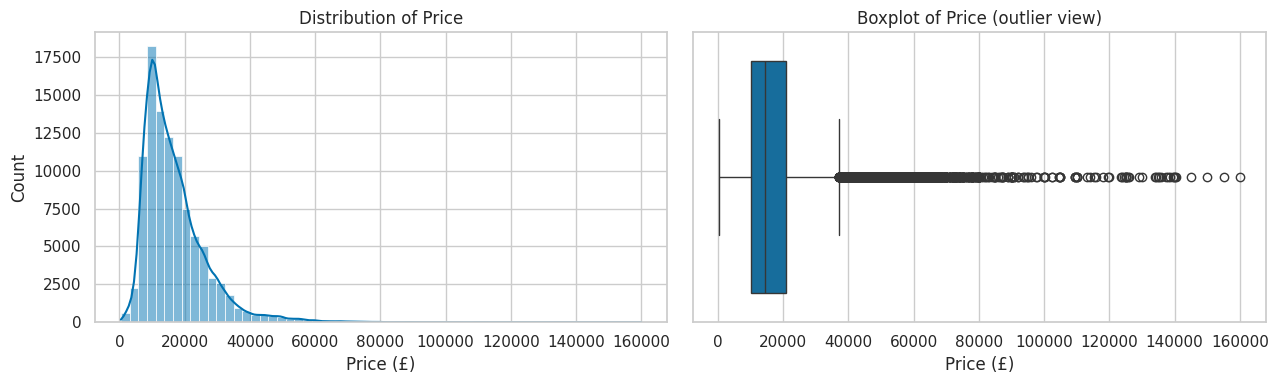

In [6]:
# ---- 1.5 Target distribution (price) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("Price (£)"); axes[0].set_ylabel("Count")

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot of Price (outlier view)")
axes[1].set_xlabel("Price (£)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Most cars cost between £10,000 and £21,000, but a few cost up to £160,000, so the price chart has a long tail on the right.

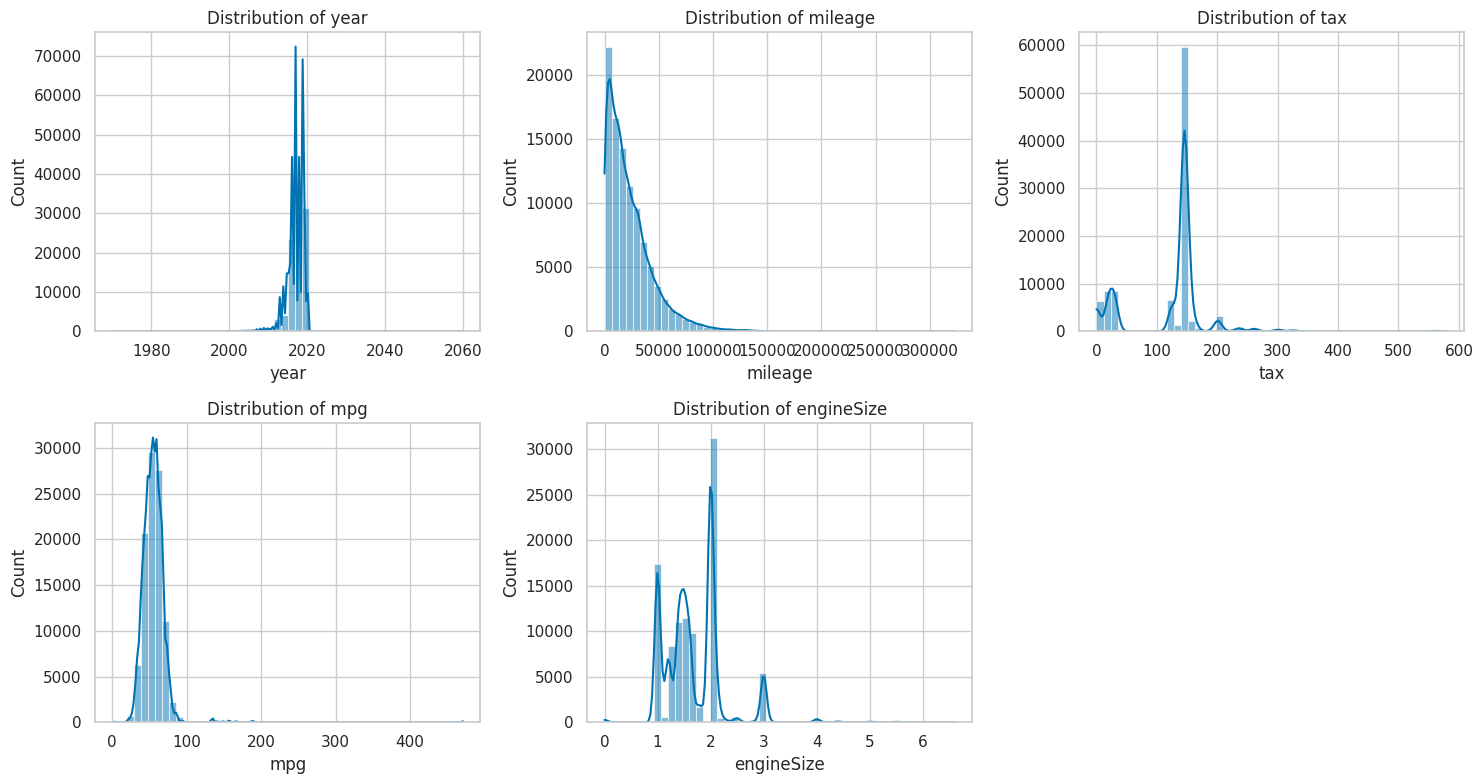

In [7]:
# ---- 1.6 Distribution plot for EACH numeric feature ----
num_features = ["year", "mileage", "tax", "mpg", "engineSize"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_features):
    sns.histplot(df[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
axes.flat[-1].set_visible(False)       # hide the unused 6th subplot
plt.tight_layout(); plt.show()

**📝 What this shows:** Most cars are recent and low-mileage, and there are a few impossible values: one car dated 2060, some with 470 mpg, and 266 with a 0-litre engine.

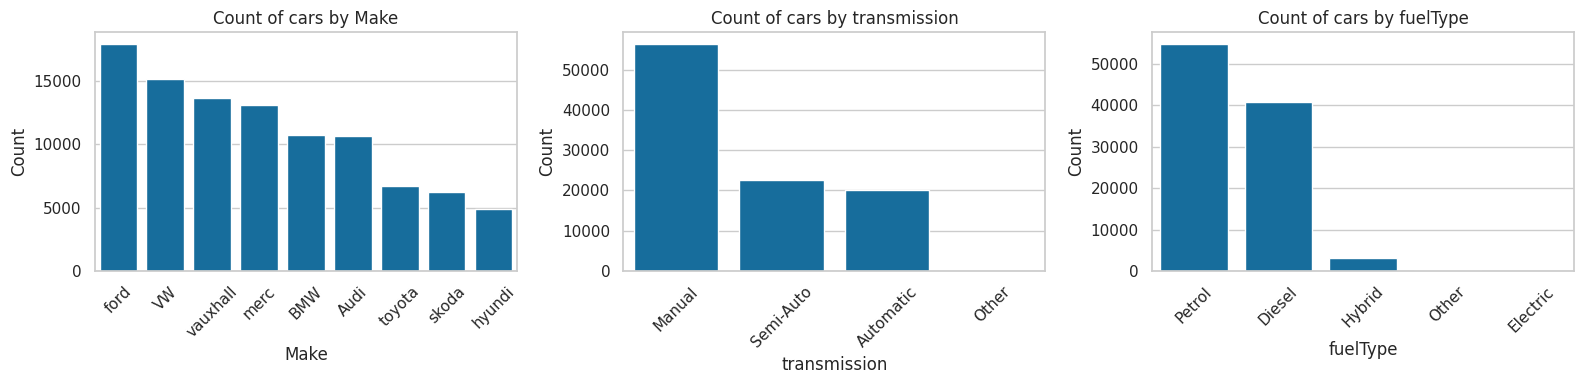

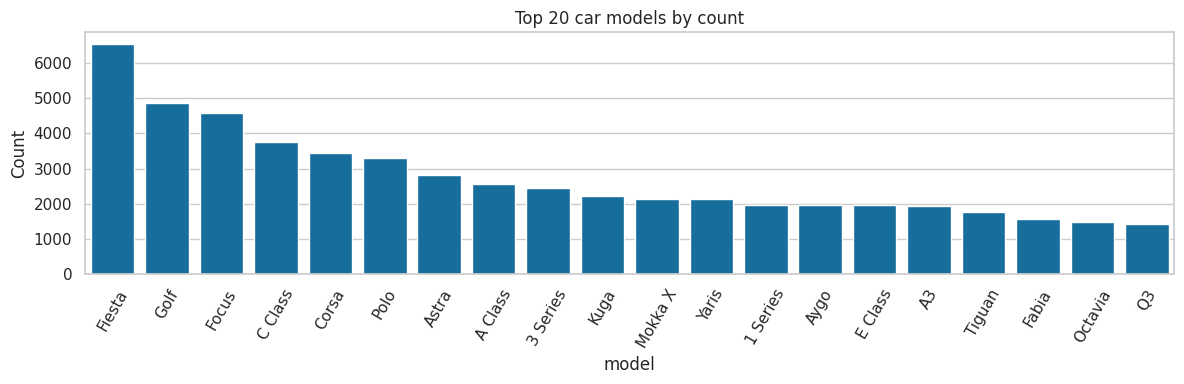

In [8]:
# ---- 1.7 Distribution plot for EACH categorical feature ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Make", "transmission", "fuelType"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f"Count of cars by {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# 'model' has ~195 values -> show only the top 20
plt.figure(figsize=(12, 4))
top_models = df["model"].value_counts().head(20)
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 20 car models by count")
plt.xlabel("model"); plt.ylabel("Count"); plt.xticks(rotation=60)
plt.tight_layout(); plt.show()

**📝 What this shows:** Ford and VW are the most common brands, most cars are manual, and petrol and diesel cover nearly everything — electric cars are almost absent (only 6).

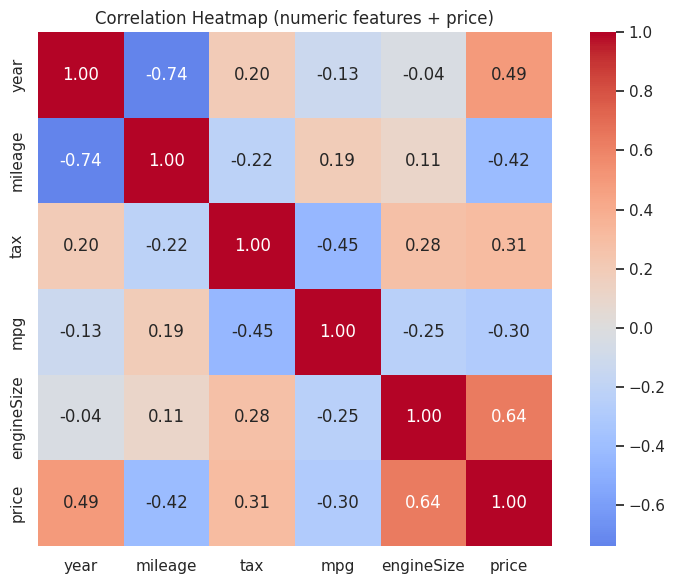

In [9]:
# ---- 1.8 Correlation heatmap (numeric columns incl. target) ----
plt.figure(figsize=(8, 6))
corr = df[num_features + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features + price)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Price goes up with engine size (0.65) and newer year (0.49), and goes down as mileage rises (−0.42).

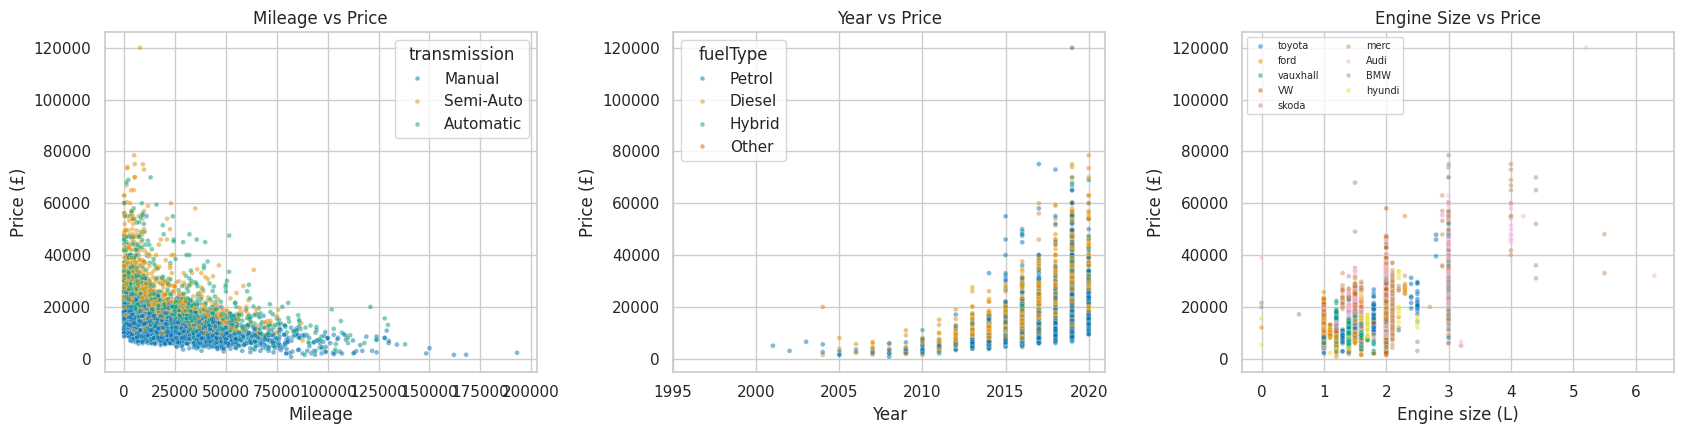

In [10]:
# ---- 1.9 Scatter plots: feature vs target ----
sample = df.sample(5000, random_state=RANDOM_STATE)   # sample so the plot is readable

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=sample, x="mileage", y=TARGET, hue="transmission", alpha=0.5, s=12, ax=axes[0])
axes[0].set_title("Mileage vs Price"); axes[0].set_xlabel("Mileage"); axes[0].set_ylabel("Price (£)")

sns.scatterplot(data=sample, x="year", y=TARGET, hue="fuelType", alpha=0.5, s=12, ax=axes[1])
axes[1].set_title("Year vs Price"); axes[1].set_xlabel("Year"); axes[1].set_ylabel("Price (£)")
axes[1].set_xlim(1995, 2021)

sns.scatterplot(data=sample, x="engineSize", y=TARGET, hue="Make", alpha=0.5, s=12, ax=axes[2])
axes[2].set_title("Engine Size vs Price"); axes[2].set_xlabel("Engine size (L)"); axes[2].set_ylabel("Price (£)")
axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

**📝 What this shows:** The lines are curved, not straight: price drops fast in the first few years and miles, then flattens out.

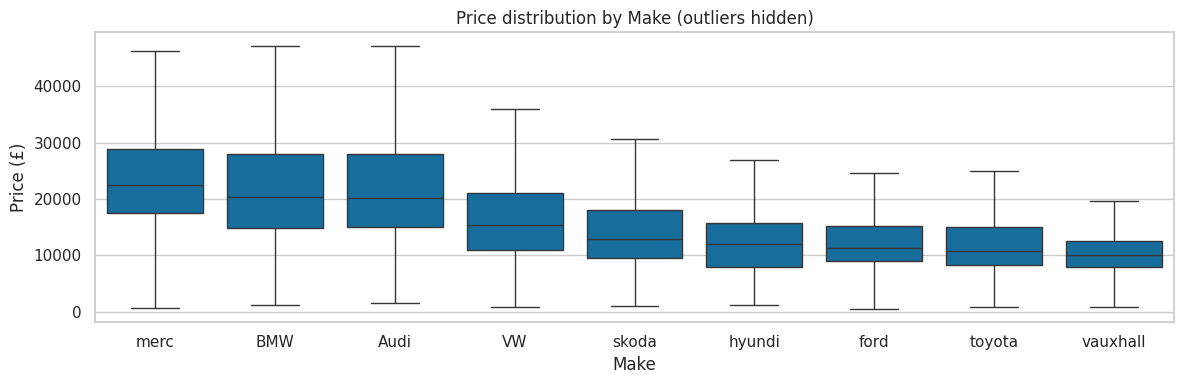

In [11]:
# ---- 1.10 Price by brand (categorical feature vs target) ----
plt.figure(figsize=(12, 4))
order = df.groupby("Make")[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Make", y=TARGET, order=order, showfliers=False)
plt.title("Price distribution by Make (outliers hidden)")
plt.xlabel("Make"); plt.ylabel("Price (£)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Mercedes, BMW and Audi cost about twice as much as Vauxhall and Toyota, so the brand matters a lot.

---
# BLOCK 2 — Preprocessing & Feature Engineering (Section B)

In [12]:
# ============================================================
# BLOCK 2 : PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ---- 2.1 Remove duplicate rows ----
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}  ->  rows now: {len(df)}")

# ---- 2.2 Remove impossible / invalid rows ----
# year > 2020 is impossible for this dataset (data was collected in 2020)
invalid_year = df["year"] > 2020
print("Rows with invalid year (>2020):", invalid_year.sum())
df = df[~invalid_year].reset_index(drop=True)

# ---- 2.3 Hidden missing values ----
# The CSV has no NaNs, but engineSize = 0 is not a real engine size for petrol/diesel cars,
# so we treat it as 'missing' and impute it later (after the split, using train data only).
hidden_missing = (df["engineSize"] == 0) & (df["fuelType"] != "Electric")
print("engineSize == 0 (treated as missing):", hidden_missing.sum())
df.loc[hidden_missing, "engineSize"] = np.nan
print("\nMissing values now:\n", df.isnull().sum()[df.isnull().sum() > 0])

Duplicates removed: 1475  ->  rows now: 97712
Rows with invalid year (>2020): 1
engineSize == 0 (treated as missing): 266

Missing values now:
 engineSize    266
dtype: int64


**Missing-value strategy:** `engineSize` NaNs are filled with the **median engine size of the same car model**
(computed on the training set only), falling back to the overall training median. The same model almost always
has a similar engine, and the median is robust to outliers.

## B3 — Feature engineering

In [13]:
# ---- 2.4 Engineered features ----
REF_YEAR = 2020                                            # year the data was collected
df["car_age"] = REF_YEAR - df["year"]                      # age of the car in years
df["mileage_per_year"] = df["mileage"] / (df["car_age"] + 1)   # +1 avoids divide-by-zero for 2020 cars

df[["year", "car_age", "mileage", "mileage_per_year", TARGET]].corr()[TARGET]

year                0.492556
car_age            -0.492556
mileage            -0.417987
mileage_per_year   -0.294263
price               1.000000
Name: price, dtype: float64

**Why these features may help:**
- `car_age` — depreciation depends on how old a car is; age is easier to interpret than the raw year.
- `mileage_per_year` — separates a *heavily used* young car from a *lightly used* old car, which raw
  mileage alone cannot do. Usage intensity affects wear and resale value.

## B2 — Stratified train/test split, encoding & scaling

In [14]:
# ---- 2.5 Separate features and target ----
cat_cols = ["model", "transmission", "fuelType", "Make"]
num_cols = ["mileage", "tax", "mpg", "engineSize", "car_age", "mileage_per_year"]
# ('year' is dropped because car_age carries the same information)

X = df[cat_cols + num_cols]
y = df[TARGET]

# ---- 2.6 Stratified 80:20 split ----
# price is continuous, so we stratify on price *bins* (quintiles)
# -> train and test get the same spread of cheap / mid / expensive cars
price_bins = pd.qcut(y, q=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=price_bins
)
X_train, X_test = X_train.copy(), X_test.copy()
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Mean price  train: %.0f | test: %.0f" % (y_train.mean(), y_test.mean()))

Train: (78168, 10)  Test: (19543, 10)
Mean price  train: 16778 | test: 16756


In [15]:
# ---- 2.7 Impute engineSize (statistics from TRAIN only) ----
model_median = X_train.groupby("model")["engineSize"].median()
global_median = X_train["engineSize"].median()

for part in (X_train, X_test):
    part["engineSize"] = part["engineSize"].fillna(part["model"].map(model_median)).fillna(global_median)

print("Missing after imputation -> train:", X_train.isnull().sum().sum(), "| test:", X_test.isnull().sum().sum())

Missing after imputation -> train: 0 | test: 0


In [16]:
# ---- 2.8 Outlier check (IQR) & treatment (capping) ----
outlier_report = {}
caps = {}
for col in ["mileage", "tax", "mpg", "engineSize", "mileage_per_year"]:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = int(((X_train[col] < low) | (X_train[col] > high)).sum())
    # Cap at the 1st / 99th percentile of TRAIN (keeps rows, limits extreme values)
    caps[col] = (X_train[col].quantile(0.01), X_train[col].quantile(0.99))

print("IQR outliers in train set:")
print(pd.Series(outlier_report))

for col, (lo, hi) in caps.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)     # same train-derived limits applied to test

IQR outliers in train set:
mileage              3075
tax                 22880
mpg                   712
engineSize            548
mileage_per_year     1773
dtype: int64


**Outlier strategy:** values are **capped** at the train-set 1st/99th percentiles instead of deleted — rows are kept,
but impossible values (e.g. mpg = 470) can no longer distort the model. The target `price` is **not** capped,
because expensive cars are genuine.

In [17]:
# ---- 2.9 Encoding + scaling (fitted on TRAIN only -> no data leakage) ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                                   # scale numeric features
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),  # one-hot encode categoricals
])

X_train_p = preprocessor.fit_transform(X_train)    # FIT + transform on train
X_test_p = preprocessor.transform(X_test)          # ONLY transform on test

feature_names = preprocessor.get_feature_names_out()
print("Processed train shape:", X_train_p.shape)
print("Processed test shape :", X_test_p.shape)

Processed train shape: (78168, 218)
Processed test shape : (19543, 218)


---
# BLOCK 3 — Regression Track: Support Vector Regressor (Section C)

**Why a subsample?** Kernel SVR training time grows roughly with the **square** of the number of rows
(a 10k-row fit takes ~10 s, so 78k rows would take well over 10 minutes per fit, and a grid search would take hours).
So we:
1. tune C / kernel / gamma on a **5,000-row** stratified subsample,
2. train the final model on a **20,000-row** stratified subsample (`N_FINAL`, can be increased if your machine is fast),
3. evaluate on the **same full test set** as all other models, so the comparison stays fair.

**Target scaling:** `price` is in thousands of pounds, while SVR's default tube width is ε = 0.1. We wrap the model in
`TransformedTargetRegressor`, which standardises `y` (fitted on the training targets only) and converts predictions back to £.

In [18]:
# ============================================================
# BLOCK 3 : REGRESSION — SUPPORT VECTOR REGRESSOR (SVR)
# ============================================================
import time
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def regression_metrics(y_true, y_hat):
    # returns R2, RMSE and MAE as a dict
    return {
        "R2": r2_score(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "MAE": mean_absolute_error(y_true, y_hat),
    }

def stratified_subsample(n, seed=RANDOM_STATE):
    # returns row positions of a price-stratified subsample of the training set
    idx, _ = train_test_split(np.arange(len(X_train_p)), train_size=n, random_state=seed,
                              stratify=pd.qcut(y_train, q=5, labels=False))
    return idx

def make_svr(**params):
    # SVR with the target standardised (and predictions converted back to £)
    return TransformedTargetRegressor(regressor=SVR(cache_size=1000, **params), transformer=StandardScaler())

N_TUNE, N_FINAL = 5000, 20000
tune_idx = stratified_subsample(N_TUNE)
final_idx = stratified_subsample(N_FINAL)
X_fin, y_fin = X_train_p[final_idx], y_train.values[final_idx]

# ---- 3.1 Train a default SVR (rbf kernel, C=1, NO target scaling) ----
start = time.time()
svr_default = SVR(cache_size=1000)
svr_default.fit(X_fin, y_fin)
print(f"Training time: {time.time() - start:.1f} s on {N_FINAL} rows")

# ---- 3.2 Predictions ----
y_pred_default = svr_default.predict(X_test_p)
print("First 5 predictions:", np.round(y_pred_default[:5], 0))
print("First 5 actual     :", y_test.values[:5])

default_scores = regression_metrics(y_test, y_pred_default)
pd.DataFrame([default_scores], index=["SVR default (rbf, C=1, unscaled target)"]).round(4)

Training time: 33.5 s on 20000 rows


First 5 predictions: [14289. 15304. 13700. 14491. 15327.]
First 5 actual     : [14995 26995  8198 11499 19465]


,R2,RMSE,MAE
"SVR default (rbf, C=1, unscaled target)",0.084,9502.1805,6131.1251


**📝 What this shows:** It predicted about £14,000 for every car, because the default settings expect small numbers and prices are in thousands.

## Impact of scaling

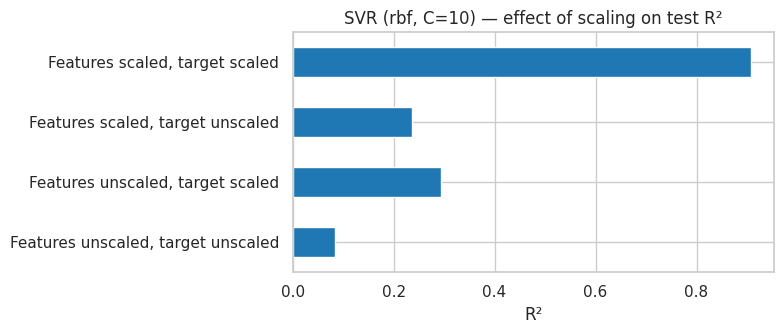

,fit_time_s,R2,RMSE,MAE
setup,,,,
"Features unscaled, target unscaled",2.1629,0.0835,9701.3911,6381.6848
"Features unscaled, target scaled",2.0207,0.2933,8518.5339,5555.8408
"Features scaled, target unscaled",2.0943,0.2358,8858.3444,5362.3608
"Features scaled, target scaled",2.4783,0.9080,3074.1122,1533.1604


In [19]:
# ---- 3.3 Scaling experiment on the 5,000-row subsample ----
# Build an UNSCALED version of the numeric features (one-hot columns stay the same)
unscaled_prep = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_train_raw = unscaled_prep.fit_transform(X_train)     # fitted on train only
X_test_raw = unscaled_prep.transform(X_test)

X_tune_s, X_tune_raw, y_tune = X_train_p[tune_idx], X_train_raw[tune_idx], y_train.values[tune_idx]
test_rows = slice(0, 5000)   # quick check on 5,000 test rows

experiments = {
    "Features unscaled, target unscaled": (SVR(C=10), X_tune_raw, X_test_raw),
    "Features unscaled, target scaled":   (make_svr(C=10), X_tune_raw, X_test_raw),
    "Features scaled, target unscaled":   (SVR(C=10), X_tune_s, X_test_p),
    "Features scaled, target scaled":     (make_svr(C=10), X_tune_s, X_test_p),
}
scale_rows = []
for name, (model, Xtr, Xte) in experiments.items():
    start = time.time()
    model.fit(Xtr, y_tune)
    scale_rows.append({"setup": name, "fit_time_s": time.time() - start,
                       **regression_metrics(y_test.values[test_rows], model.predict(Xte[test_rows]))})
scale_df = pd.DataFrame(scale_rows).set_index("setup")

scale_df["R2"].plot(kind="barh", figsize=(8, 3.5), color="tab:blue")
plt.title("SVR (rbf, C=10) — effect of scaling on test R²")
plt.xlabel("R²"); plt.ylabel("")
plt.tight_layout(); plt.show()
scale_df.round(4)

**📝 What this shows:** Scaling the features and the price together lifted the score from 0.08 to 0.91 — doing just one of them is not enough.

## C3 — Hyperparameter tuning (kernel, C, gamma)

In [20]:
# ---- 3.4 GridSearchCV over kernel, C and gamma (5,000-row subsample) ----
# parameters of the inner SVR are addressed as 'regressor__<name>'
param_grid = [
    {"regressor__kernel": ["rbf"],    "regressor__C": [1, 10, 100], "regressor__gamma": ["scale", 0.01, 0.1]},
    {"regressor__kernel": ["poly"],   "regressor__C": [1, 10, 100], "regressor__degree": [2, 3]},
    {"regressor__kernel": ["linear"], "regressor__C": [0.1, 1, 10]},
]
grid = GridSearchCV(make_svr(), param_grid, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                    scoring="r2", n_jobs=-1, return_train_score=True, refit=False)
start = time.time()
grid.fit(X_tune_s, y_tune)
print(f"Search time: {time.time() - start:.1f} s")

best_params = {k.replace("regressor__", ""): v for k, v in grid.best_params_.items()}
print("Best parameters :", best_params)
print("Best CV R2 (5k subsample): %.4f" % grid.best_score_)

cv_res = pd.DataFrame(grid.cv_results_)
cv_res["setting"] = cv_res["params"].apply(lambda p: ", ".join(f"{k.replace('regressor__', '')}={v}" for k, v in p.items()))
cv_res[["setting", "mean_train_score", "mean_test_score", "mean_fit_time"]] \
    .sort_values("mean_test_score", ascending=False).round(4)

Search time: 323.5 s
Best parameters : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV R2 (5k subsample): 0.9248


,setting,mean_train_score,mean_test_score,mean_fit_time
7,"C=100, gamma=0.01, kernel=rbf",0.9496,0.9248,1.9281
3,"C=10, gamma=scale, kernel=rbf",0.9746,0.9230,1.1385
5,"C=10, gamma=0.1, kernel=rbf",0.9743,0.9229,1.0402
11,"C=10, degree=2, kernel=poly",0.9550,0.9196,2.6999
13,"C=100, degree=2, kernel=poly",0.9616,0.9146,35.2594
8,"C=100, gamma=0.1, kernel=rbf",0.9875,0.9125,2.6760
6,"C=100, gamma=scale, kernel=rbf",0.9875,0.9123,2.6826
10,"C=1, degree=3, kernel=poly",0.9487,0.9042,0.8816
9,"C=1, degree=2, kernel=poly",0.9182,0.8995,0.6704
4,"C=10, gamma=0.01, kernel=rbf",0.9100,0.8986,0.6541


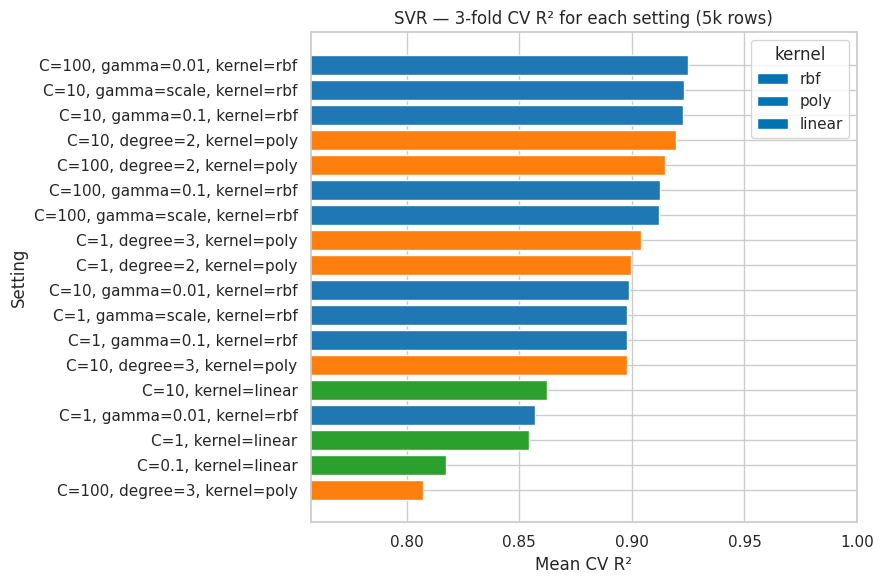

In [21]:
# ---- 3.5 Plot: CV R2 for every kernel / C combination ----
plot_df = cv_res.sort_values("mean_test_score")
colors = plot_df["param_regressor__kernel"].map({"rbf": "tab:blue", "poly": "tab:orange", "linear": "tab:green"})
plt.figure(figsize=(9, 6))
plt.barh(plot_df["setting"], plot_df["mean_test_score"], color=colors)
for k, c in {"rbf": "tab:blue", "poly": "tab:orange", "linear": "tab:green"}.items():
    plt.barh([], [], color=c, label=k)
plt.xlim(max(0, plot_df["mean_test_score"].min() - 0.05), 1)
plt.title("SVR — 3-fold CV R² for each setting (5k rows)")
plt.xlabel("Mean CV R²"); plt.ylabel("Setting")
plt.legend(title="kernel"); plt.tight_layout(); plt.show()

**📝 What this shows:** The RBF kernel wins with C=100, and a bigger C fits better but takes much longer to train.

In [22]:
# ---- 3.6 Does more training data help? (best settings, growing sample size) ----
# scored on a 5,000-row validation set taken from the training rows NOT used in the final sample
val_pool = np.setdiff1d(np.arange(len(X_train_p)), final_idx)
val_idx = np.random.RandomState(RANDOM_STATE).choice(val_pool, 5000, replace=False)

size_rows = []
for n in [2500, 5000, 10000]:
    idx = stratified_subsample(n)
    start = time.time()
    m = make_svr(**best_params).fit(X_train_p[idx], y_train.values[idx])
    size_rows.append({"train_rows": n, "fit_time_s": time.time() - start,
                      "val_R2": r2_score(y_train.values[val_idx], m.predict(X_train_p[val_idx]))})
size_df = pd.DataFrame(size_rows)
size_df.round(4)

,train_rows,fit_time_s,val_R2
0,2500,1.2932,0.8786
1,5000,4.2538,0.8840
2,10000,16.0770,0.9013


Training time: 63.8 s | support vectors: 8923 of 20000 rows


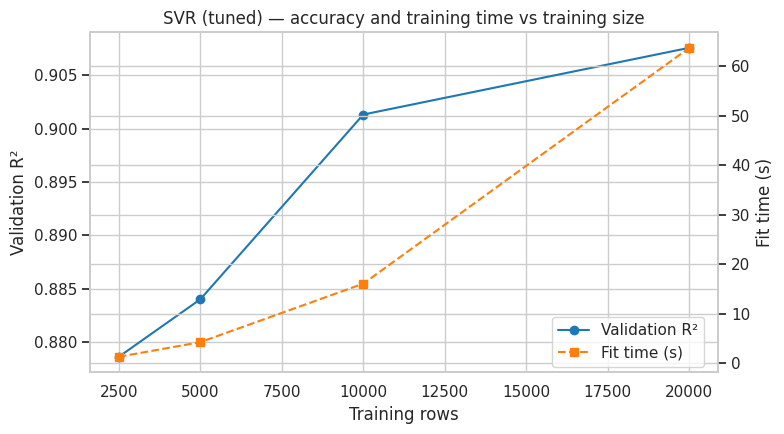

Train R2 (tuned, 5k of its training rows): 0.9487 | Test R2: 0.9248


,R2,RMSE,MAE
"SVR default (C=1, unscaled target)",0.0840,9502.1805,6131.1251
"SVR tuned {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}",0.9248,2721.9150,1369.9773
Improvement,0.8409,-6780.2655,-4761.1478


In [23]:
# ---- 3.7 Train the FINAL tuned SVR on 20,000 rows & report improvement ----
start = time.time()
svr_best = make_svr(**best_params).fit(X_fin, y_fin)
fit_time = time.time() - start
print(f"Training time: {fit_time:.1f} s | support vectors: {svr_best.regressor_.support_.size} of {N_FINAL} rows")

y_pred = svr_best.predict(X_test_p)
tuned_scores = regression_metrics(y_test, y_pred)

# add the 20k point to the sample-size curve
size_df = pd.concat([size_df, pd.DataFrame([{"train_rows": N_FINAL, "fit_time_s": fit_time,
                     "val_R2": r2_score(y_train.values[val_idx], svr_best.predict(X_train_p[val_idx]))}])], ignore_index=True)
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(size_df["train_rows"], size_df["val_R2"], "o-", color="tab:blue", label="Validation R²")
ax1.set_xlabel("Training rows"); ax1.set_ylabel("Validation R²")
ax2 = ax1.twinx()
ax2.plot(size_df["train_rows"], size_df["fit_time_s"], "s--", color="tab:orange", label="Fit time (s)")
ax2.set_ylabel("Fit time (s)")
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.15))
plt.title("SVR (tuned) — accuracy and training time vs training size")
plt.tight_layout(); plt.show()

compare = pd.DataFrame([default_scores, tuned_scores],
                       index=["SVR default (C=1, unscaled target)", f"SVR tuned {best_params}"])
compare.loc["Improvement"] = compare.iloc[1] - compare.iloc[0]
train_check = np.random.RandomState(1).choice(N_FINAL, 5000, replace=False)
print("Train R2 (tuned, 5k of its training rows): %.4f | Test R2: %.4f"
      % (r2_score(y_fin[train_check], svr_best.predict(X_fin[train_check])), tuned_scores["R2"]))
compare.round(4)

**📝 What this shows:** Doubling the data adds only a tiny bit of accuracy but makes training 3 to 4 times slower.

In [24]:
# ---- 3.8 5-fold cross-validated R2 (on the 20,000-row training sample) ----
# (this cell trains 5 SVRs and can take a couple of minutes)
cv_scores = cross_val_score(make_svr(**best_params), X_fin, y_fin, cv=kf, scoring="r2")
print("CV R2 per fold:", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f}  (± {cv_scores.std():.4f})")

CV R2 per fold: [0.9172 0.9304 0.9432 0.9268 0.9443]
Mean CV R2: 0.9324  (± 0.0103)


## C4 — Visualisation

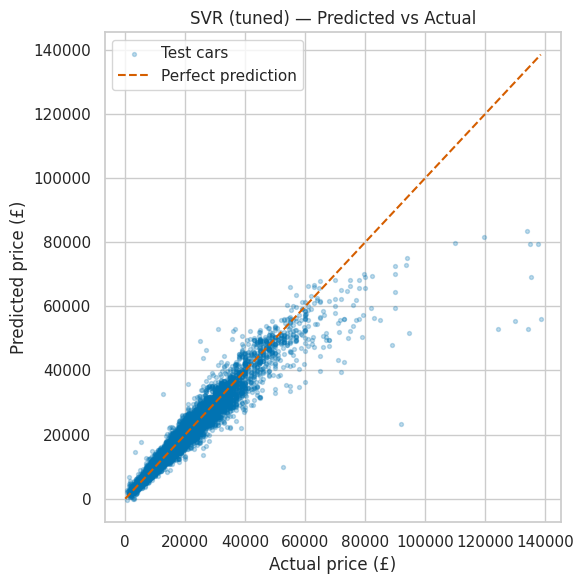

In [25]:
# ---- 3.9 Predicted vs Actual ----
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.25, s=8, label="Test cars")
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.title("SVR (tuned) — Predicted vs Actual")
plt.xlabel("Actual price (£)"); plt.ylabel("Predicted price (£)")
plt.legend(); plt.tight_layout(); plt.show()

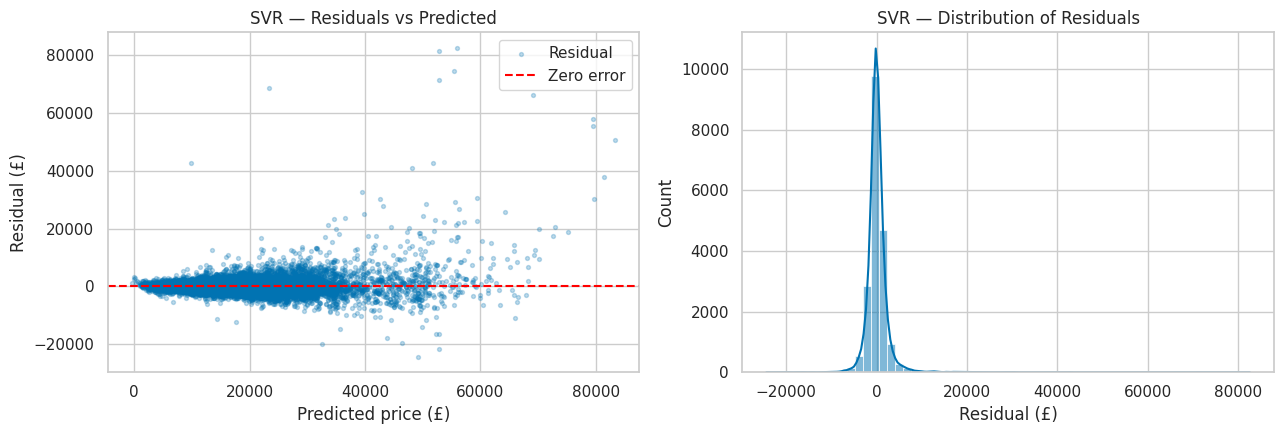

In [26]:
# ---- 3.10 Residual plots ----
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_pred, residuals, alpha=0.25, s=8, label="Residual")
axes[0].axhline(0, color="red", linestyle="--", label="Zero error")
axes[0].set_title("SVR — Residuals vs Predicted")
axes[0].set_xlabel("Predicted price (£)"); axes[0].set_ylabel("Residual (£)"); axes[0].legend()

sns.histplot(residuals, bins=60, kde=True, ax=axes[1])
axes[1].set_title("SVR — Distribution of Residuals")
axes[1].set_xlabel("Residual (£)"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()

**📝 What this shows:** The errors are bigger than the tree models, especially for expensive cars, partly because SVR only saw 20,000 cars.

In [27]:
# ---- 3.11 Save results for the final 10-model comparison table ----
os.makedirs("../results", exist_ok=True)
RESULTS_FILE = "../results/regression_results.csv"
MODEL_NAME = "Support Vector Regressor"

row = pd.DataFrame([{
    "Model": MODEL_NAME,
    **tuned_scores,
    "CV_R2_mean": cv_scores.mean(),
    "Tuned": "Yes (GridSearchCV)",
    "Best_params": str({**best_params, "train_rows": N_FINAL}),
}])
if os.path.exists(RESULTS_FILE):
    old = pd.read_csv(RESULTS_FILE)
    row = pd.concat([old[old["Model"] != MODEL_NAME], row], ignore_index=True)
row.to_csv(RESULTS_FILE, index=False)
row.round(4)

,Model,R2,RMSE,MAE,CV_R2_mean,Tuned,Best_params
0,Linear Regression,0.8581,3740.5466,2236.4595,0.8641,No (baseline),-
1,Ridge Regression,0.8581,3740.4517,2236.5020,0.8641,Yes (GridSearchCV),"{'alpha': 0.03162, 'solver': 'auto'}"
2,Lasso Regression,0.8580,3740.9234,2236.8250,0.8641,Yes (GridSearchCV),{'alpha': 0.01}
3,ElasticNet Regression,0.8580,3741.4670,2236.9651,0.8641,Yes (GridSearchCV),"{'alpha': 0.001, 'l1_ratio': 1.0}"
4,Polynomial Regression,0.9114,2955.0887,1728.8830,0.9151,Yes (GridSearchCV),"{'degree': 3, 'interaction_only': False}"
5,Decision Tree Regressor,0.9416,2398.3671,1360.5098,0.9311,Yes (GridSearchCV),"{'max_depth': 25, 'min_samples_leaf': 3}"
6,Random Forest Regressor,0.9594,2001.0139,1163.3206,0.9554,Yes (RandomizedSearchCV),"{'n_estimators': 150, 'min_samples_leaf': 1, '..."
7,Gradient Boosting Regressor,0.9619,1938.0616,1114.0200,0.9596,Yes (RandomizedSearchCV),"{'min_samples_leaf': 5, 'max_leaf_nodes': 127,..."
8,Support Vector Regressor,0.9248,2721.9150,1369.9773,0.9324,Yes (GridSearchCV),"{'C': 100, 'gamma': 0.01, 'kernel': 'rbf', 'tr..."


## Summary

**📝 In short:** SVR scores 0.925 but is far too slow for 78,000 cars, so the tree models are the better choice here.